### Create the original research dataset

This cell creates the first version of the original research dataset, `research_data.csv`, using trials 1 and 2. It stores the trial date, condition, heart rate values, completion time, and side notes. It also calculates HRR using post-exercise heart rate minus heart rate after 60 seconds. To avoid accidentally overwriting later trial data, the cell only creates the file if it does not already exist.

In [1]:
# Import pandas for creating and working with the dataset
import pandas as pd

# Import Path to build file paths that work reliably across folders
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the data folder
data_folder = project_root / "data"

# Create the data folder if it does not already exist
data_folder.mkdir(exist_ok=True)

# Set the path where the original research dataset will be saved
data_path = data_folder / "research_data.csv"

# Only create the starting CSV file if it does not already exist.
# This prevents accidentally overwriting later trial data by rerunning this cell.
if data_path.exists():
    print("research_data.csv already exists, so it was not overwritten.")

    # Load the existing dataset instead
    df = pd.read_csv(data_path)
else:
    # Create the starting data for trials 1 and 2
    data = {
        "trial_id": [1, 2],
        "date": ["2026-06-21", "2026-06-21"],
        "condition": ["calm", "stress"],
        "resting_hr": [75, 75],
        "post_exercise_hr": [141, 144],
        "hr_60s": [83, 86],
        "completion_time": ["N/A", "2:17.46"],
        "side_notes": [
            "Approx 2h after hitting with Richard, 8 hours of sleep, 0 mistakes made while skipping",
            "Approx 2h after hitting with Richard, 8 hours of sleep, 7 mistakes made while skipping"
        ]
    }

    # Convert the dictionary into a pandas DataFrame
    df = pd.DataFrame(data)

    # Calculate heart rate recovery.
    # HRR = post-exercise heart rate minus heart rate after 60 seconds.
    df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

    # Reorder the columns so the table is easier to read
    df = df[
        [
            "trial_id",
            "date",
            "condition",
            "resting_hr",
            "post_exercise_hr",
            "hr_60s",
            "hrr",
            "completion_time",
            "side_notes"
        ]
    ]

    # Save the starting dataset as research_data.csv
    df.to_csv(data_path, index=False)

    print("research_data.csv was created.")

# Display the dataset in the notebook
df

research_data.csv already exists, so it was not overwritten.


,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes,exertion_scale,stress_scale
0,1,2026-06-21,calm,75,141,83,58,NaN,"Approx 2h after hitting with Richard, 8 hours ...",6.0,3.0
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ...",5.5,6.5
2,3,2026-06-24,calm,75,143,88,55,NaN,8 hours of sleep; timer shut off at 50 seconds...,5.5,3.0
3,4,2026-06-24,stress,75,153,91,62,2:03.30,8 hours of sleep; approximately 3 hours and 30...,6.5,6.5
4,5,2026-06-25,calm,70,135,81,54,NaN,About 8 hours sleep (maybe 8.5); 2 mistakes we...,4.5,2.0
5,6,2026-06-25,stress,70,134,76,58,1:30.76,About 8 hours sleep (maybe 8.5); 5 mistakes we...,5.0,5.5


### Load and display the original research dataset

This cell loads the original full research dataset saved as `research_data.csv`. Displaying the table helps confirm that the file was read correctly and allows the dataset to be checked before adding new trials, editing columns, or running analysis.

In [2]:
# Import pandas for reading and working with the dataset
import pandas as pd

# Import Path to build file paths that work reliably across folders
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the original full research dataset
data_path = project_root / "data" / "research_data.csv"

# Load the original research dataset from the CSV file
df = pd.read_csv(data_path)

# Display the dataset in the notebook so I can check that it loaded correctly
df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes,exertion_scale,stress_scale
0,1,2026-06-21,calm,75,141,83,58,NaN,"Approx 2h after hitting with Richard, 8 hours ...",6.0,3.0
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ...",5.5,6.5
2,3,2026-06-24,calm,75,143,88,55,NaN,8 hours of sleep; timer shut off at 50 seconds...,5.5,3.0
3,4,2026-06-24,stress,75,153,91,62,2:03.30,8 hours of sleep; approximately 3 hours and 30...,6.5,6.5
4,5,2026-06-25,calm,70,135,81,54,NaN,About 8 hours sleep (maybe 8.5); 2 mistakes we...,4.5,2.0
5,6,2026-06-25,stress,70,134,76,58,1:30.76,About 8 hours sleep (maybe 8.5); 5 mistakes we...,5.0,5.5


### Add scale columns and trials 3 and 4 to the original research dataset

This cell updates the original research dataset saved as `research_data.csv`. It adds the exertion scale and stress scale columns, fills in scale values for trials 1 and 2, adds trials 3 and 4, recalculates HRR from the heart rate values, and saves the updated table. This keeps the original full research table organized with heart rate data, side notes, completion time, and scale ratings.

In [3]:
# Import libraries for data analysis and file path handling
import pandas as pd
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the original full research dataset
data_path = project_root / "data" / "research_data.csv"

# Load the current research dataset from the CSV file
df = pd.read_csv(data_path, keep_default_na=False)

# Convert trial_id to a number so trials can be filtered and sorted correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Add the exertion scale column if it does not already exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

# Add the stress scale column if it does not already exist
if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

# Convert the scale columns to numeric values that can hold decimals like 5.5
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Float64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Float64")

# Add scale values for the existing first two trials
df.loc[df["trial_id"] == 1, "exertion_scale"] = 6.0
df.loc[df["trial_id"] == 1, "stress_scale"] = 3.0

df.loc[df["trial_id"] == 2, "exertion_scale"] = 5.5
df.loc[df["trial_id"] == 2, "stress_scale"] = 6.5

# Remove trials 3 and 4 first so rerunning this cell does not create duplicate rows
df = df[~df["trial_id"].isin([3, 4])]

# Create new rows for trials 3 and 4
new_rows = pd.DataFrame([
    {
        "trial_id": 3,
        "date": "2026-06-24",
        "condition": "calm",
        "resting_hr": 75,
        "post_exercise_hr": 143,
        "hr_60s": 88,
        "hrr": 55,
        "completion_time": "N/A",
        "side_notes": "8 hours of sleep; timer shut off at 50 seconds remaining, had to guess; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 3 mistakes were made while skipping",
        "exertion_scale": 5.5,
        "stress_scale": 3.0
    },
    {
        "trial_id": 4,
        "date": "2026-06-24",
        "condition": "stress",
        "resting_hr": 75,
        "post_exercise_hr": 153,
        "hr_60s": 91,
        "hrr": 62,
        "completion_time": "2:03.30",
        "side_notes": "8 hours of sleep; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 4 mistakes were made while skipping; made a mistake when doing serial sevens test - did not end at 4, ended on 6",
        "exertion_scale": 6.5,
        "stress_scale": 6.5
    }
])

# Add the new trial rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# Convert the heart rate columns to numbers so HRR can be calculated correctly
df["post_exercise_hr"] = pd.to_numeric(df["post_exercise_hr"], errors="coerce")
df["hr_60s"] = pd.to_numeric(df["hr_60s"], errors="coerce")

# Recalculate HRR from the raw heart rate values to avoid manual calculation errors
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

# Sort the dataset by trial number so the table stays organized
df = df.sort_values("trial_id").reset_index(drop=True)

# Save the updated research dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the updated table so I can check that trials 3 and 4 were added correctly
df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes,exertion_scale,stress_scale
0,1,2026-06-21,calm,75,141,83,58,N/A,"Approx 2h after hitting with Richard, 8 hours ...",6.0,3.0
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ...",5.5,6.5
2,3,2026-06-24,calm,75,143,88,55,N/A,8 hours of sleep; timer shut off at 50 seconds...,5.5,3.0
3,4,2026-06-24,stress,75,153,91,62,2:03.30,8 hours of sleep; approximately 3 hours and 30...,6.5,6.5
4,5,2026-06-25,calm,70,135,81,54,N/A,About 8 hours sleep (maybe 8.5); 2 mistakes we...,4.5,2.0
5,6,2026-06-25,stress,70,134,76,58,1:30.76,About 8 hours sleep (maybe 8.5); 5 mistakes we...,5.0,5.5


### Add trials 5 and 6 to the original research dataset

This cell adds trials 5 and 6 to the original research dataset saved as `research_data.csv`. It checks that the exertion and stress scale columns exist, allows decimal scale values, removes trials 5 and 6 before adding them again to prevent duplicates, recalculates HRR from the heart rate values, and saves the updated table. This keeps the original full research table updated with trial data, completion time, side notes, and scale ratings.

In [4]:
# Import libraries for data analysis and file path handling
import pandas as pd
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the original full research dataset
data_path = project_root / "data" / "research_data.csv"

# Load the current research dataset from the CSV file
df = pd.read_csv(data_path, keep_default_na=False)

# Convert trial_id to a number so trials can be filtered and sorted correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Add the exertion scale column if it does not already exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

# Add the stress scale column if it does not already exist
if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

# Convert the scale columns to numeric values that can hold decimals like 5.5
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Float64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Float64")

# Remove trials 5 and 6 first so rerunning this cell does not create duplicate rows
df = df[~df["trial_id"].isin([5, 6])]

# Create new rows for trials 5 and 6
new_rows = pd.DataFrame([
    {
        "trial_id": 5,
        "date": "2026-06-25",
        "condition": "calm",
        "resting_hr": 70,
        "post_exercise_hr": 135,
        "hr_60s": 81,
        "hrr": 54,
        "completion_time": "N/A",
        "side_notes": "About 8 hours sleep (maybe 8.5); 2 mistakes were made while skipping; sore in glutes from yesterday's HIIT workout; no workout or physical activity was done today",
        "exertion_scale": 4.5,
        "stress_scale": 2.0
    },
    {
        "trial_id": 6,
        "date": "2026-06-25",
        "condition": "stress",
        "resting_hr": 70,
        "post_exercise_hr": 134,
        "hr_60s": 76,
        "hrr": 58,
        "completion_time": "1:30.76",
        "side_notes": "About 8 hours sleep (maybe 8.5); 5 mistakes were made while skipping; had mild cramp after making 3 mistakes at 1:30; watch took a couple of seconds after skipping to give heart rate; sore in glutes from yesterday's HIIT workout; no workout or physical activity was done today",
        "exertion_scale": 5.0,
        "stress_scale": 5.5
    }
])

# Add the new trial rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# Convert the heart rate columns to numbers so HRR can be calculated correctly
df["post_exercise_hr"] = pd.to_numeric(df["post_exercise_hr"], errors="coerce")
df["hr_60s"] = pd.to_numeric(df["hr_60s"], errors="coerce")

# Recalculate HRR from the raw heart rate values to avoid manual calculation errors
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

# Sort the dataset by trial number so the table stays organized
df = df.sort_values("trial_id").reset_index(drop=True)

# Save the updated research dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the updated table so I can check that trials 5 and 6 were added correctly
df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes,exertion_scale,stress_scale
0,1,2026-06-21,calm,75,141,83,58,N/A,"Approx 2h after hitting with Richard, 8 hours ...",6.0,3.0
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ...",5.5,6.5
2,3,2026-06-24,calm,75,143,88,55,N/A,8 hours of sleep; timer shut off at 50 seconds...,5.5,3.0
3,4,2026-06-24,stress,75,153,91,62,2:03.30,8 hours of sleep; approximately 3 hours and 30...,6.5,6.5
4,5,2026-06-25,calm,70,135,81,54,N/A,About 8 hours sleep (maybe 8.5); 2 mistakes we...,4.5,2.0
5,6,2026-06-25,stress,70,134,76,58,1:30.76,About 8 hours sleep (maybe 8.5); 5 mistakes we...,5.0,5.5


### Load and display the HRR dataset

This cell loads the saved HRR dataset from the CSV file into pandas. Displaying the dataset helps confirm that the file was read correctly and that the trial data is available for analysis.

In [5]:
# Import pandas for reading and working with the dataset
import pandas as pd

# Import Path to build file paths that work reliably across folders
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Load the HRR dataset from the data folder
df = pd.read_csv(project_root / "data" / "hrr_data.csv")

# Display the dataset in the notebook so I can check that it loaded correctly
df

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.0,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,5.5,5.0,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


### Generate summary statistics

This cell uses `df.describe()` to calculate summary statistics for the numerical columns in the dataset. These statistics include the count, mean, standard deviation, minimum, maximum, and quartiles. This helps give a quick overview of the heart rate and HRR values before doing more detailed analysis.

In [6]:
# Generate summary statistics for the numerical columns in the dataset
df.describe()

,trial_id,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale
count,16.000000,16.00000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,8.500000,73.93750,140.500000,88.937500,51.562500,5.468750,4.187500
std,4.760952,3.73218,7.384669,7.611121,7.238497,0.670044,1.621471
min,1.000000,68.00000,121.000000,76.000000,34.000000,4.500000,2.000000
25%,4.750000,72.25000,136.750000,84.000000,46.750000,5.000000,3.000000
50%,8.500000,74.50000,140.500000,87.500000,53.500000,5.500000,3.500000
75%,12.250000,75.00000,144.750000,92.000000,56.500000,6.000000,5.625000
max,16.000000,81.00000,153.000000,104.000000,62.000000,6.500000,6.500000


### Add trials 7 and 8

This cell adds trials 7 and 8 to the HRR dataset and makes sure the dataset includes the exertion scale, stress scale, and side notes columns. It recalculates HRR, saves the updated CSV file, and displays the dataset and summary statistics.

In [7]:
# Import libraries for data analysis, plotting, and file path handling
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the HRR dataset and the folder where figures will be saved
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the current HRR dataset from the CSV file
df = pd.read_csv(data_path)

# Convert trial_id to a numeric type so trials can be filtered and sorted correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Add the scale and notes columns if they do not already exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

if "side_notes" not in df.columns:
    df["side_notes"] = ""

# Convert the scale columns to numeric values that can hold decimals like 5.5
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Float64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Float64")

# Remove trials 7 and 8 first so rerunning this cell does not create duplicate rows
df = df[~df["trial_id"].isin([7, 8])]

# Create new rows for trials 7 and 8
new_rows = pd.DataFrame([
    {
        "trial_id": 7,
        "date": "2026-06-28",
        "condition": "calm",
        "pre_hr": 75,
        "post_hr": 147,
        "hr_60s": 104,
        "hrr": 43,
        "exertion_scale": 5.0,
        "stress_scale": 2.5,
        "side_notes": "About 8 hours of sleep; just over 1 hour after 1.5 hours of tennis; 0 mistakes were made while skipping"
    },
    {
        "trial_id": 8,
        "date": "2026-06-28",
        "condition": "stress",
        "pre_hr": 73,
        "post_hr": 149,
        "hr_60s": 103,
        "hrr": 46,
        "exertion_scale": 5.5,
        "stress_scale": 5.0,
        "side_notes": "About 8 hours of sleep; just over 1 hour after 1.5 hours of tennis; 0 mistakes were made while skipping"
    }
])

# Add the new rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# Recalculate HRR from the raw heart rate values to avoid manual calculation errors
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Save the updated dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the updated dataset so I can check that trials 7 and 8 were added correctly
display(df)

# Display summary statistics for the dataset
display(df.describe())

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
7,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...
8,11,2026-07-04,calm,74,121,87,34,5.0,3.5,About 8 hours of sleep; did fitness about 5 ho...
9,12,2026-07-04,stress,75,137,90,47,6.0,6.5,About 8 hours of sleep; did fitness about 5 ho...


,trial_id,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale
count,16.0,16.00000,16.000000,16.000000,16.000000,16.0,16.0
mean,8.5,73.93750,140.500000,88.937500,51.562500,5.46875,4.1875
std,4.760952,3.73218,7.384669,7.611121,7.238497,0.670044,1.621471
min,1.0,68.00000,121.000000,76.000000,34.000000,4.5,2.0
25%,4.75,72.25000,136.750000,84.000000,46.750000,5.0,3.0
50%,8.5,74.50000,140.500000,87.500000,53.500000,5.5,3.5
75%,12.25,75.00000,144.750000,92.000000,56.500000,6.0,5.625
max,16.0,81.00000,153.000000,104.000000,62.000000,6.5,6.5


### Add trials 9 and 10 and calculate mean HRR by condition

This cell adds trials 9 and 10 to the HRR dataset and saves the updated CSV file. It checks that all required columns exist, removes trials 9 and 10 before adding them again to prevent duplicates, recalculates HRR from the raw heart rate values, and then calculates the mean HRR for each condition. This helps compare the average HRR between the calm and stress trials collected so far.

In [8]:
# Import libraries for data analysis and file paths
import pandas as pd
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the HRR dataset
data_path = project_root / "data" / "hrr_data.csv"

# Load the current HRR dataset from the CSV file
df = pd.read_csv(data_path, keep_default_na=False)

# List the columns that should exist in the dataset
needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

# Add any missing columns as blank columns so the dataset structure stays consistent
for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

# Convert trial_id to a number so trials can be filtered and sorted correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Remove trials 9 and 10 first so rerunning this cell does not create duplicate rows
df = df[~df["trial_id"].isin([9, 10])]

# Create new rows for trials 9 and 10
new_rows = pd.DataFrame([
    {
        "trial_id": 9,
        "date": "2026-07-01",
        "condition": "calm",
        "pre_hr": 74,
        "post_hr": 140,
        "hr_60s": 86,
        "hrr": 54,
        "exertion_scale": 6.0,
        "stress_scale": 3.0,
        "side_notes": "About 8 hours of sleep; played 1 hour of tennis about 5 hours ago; extremely warm and humid weather about 36°C, feels like 46°C; 6 mistakes were made while skipping"
    },
    {
        "trial_id": 10,
        "date": "2026-07-01",
        "condition": "stress",
        "pre_hr": 74,
        "post_hr": 141,
        "hr_60s": 88,
        "hrr": 53,
        "exertion_scale": 6.5,
        "stress_scale": 5.0,
        "side_notes": "About 8 hours of sleep; played 1 hour of tennis about 5 hours ago; extremely warm and humid weather about 36°C, feels like 46°C; 4 mistakes were made while skipping"
    }
])

# Add the new rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# List the columns that should contain numerical values
number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

# Convert the numerical columns to number format so calculations work correctly
for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Recalculate HRR from the raw heart rate values to avoid manual calculation errors
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Sort the dataset by trial number so the table stays organized
df = df.sort_values("trial_id").reset_index(drop=True)

# Save the updated dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the updated dataset so I can check that trials 9 and 10 were added correctly
display(df)

# Calculate the mean HRR for each condition using only trials 1 to 10
first_10_trials = df[df["trial_id"] <= 10]

condition_means = first_10_trials.groupby("condition")["hrr"].mean()

# Display the mean HRR values for calm and stress trials after trials 1 to 10
display(condition_means)

# Print the mean HRR values so they are clearly visible in the notebook output
print("Mean HRR by condition after trials 1 to 10:")
print(condition_means)

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.0,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,5.5,5.0,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


condition
calm      52.8
stress    55.4
Name: hrr, dtype: float64

Mean HRR by condition after trials 1 to 10:
condition
calm      52.8
stress    55.4
Name: hrr, dtype: float64


At this point in the data collection process, after trials 1–10, the mean HRR for the calm condition was 52.8 bpm and the mean HRR for the stress condition was 55.4 bpm. These values show the average HRR for each condition at the halfway point of the experiment.

### Add trials 11 and 12 and check data quality

This cell adds trials 11 and 12 to the HRR dataset and saves the updated CSV file. It checks the full dataset, recalculates HRR from the raw heart rate values, displays HRR values sorted from lowest to highest, and checks for possible outliers using the 1.5 × IQR rule.

In [9]:
# Import libraries for data analysis, graphing, numerical calculations, and file paths
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Find the main project folder.
# If this notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the HRR dataset and the folder where graphs will be saved
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the current HRR dataset from the CSV file
df = pd.read_csv(data_path, keep_default_na=False)

# List the columns that should exist in the dataset
needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

# Add any missing columns as blank columns so the dataset structure stays consistent
for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

# Convert trial_id to a number so trials can be filtered and sorted correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Remove trials 11 and 12 first so rerunning this cell does not create duplicate rows
df = df[~df["trial_id"].isin([11, 12])]

# Create new rows for trials 11 and 12
new_rows = pd.DataFrame([
    {
        "trial_id": 11,
        "date": "2026-07-04",
        "condition": "calm",
        "pre_hr": 74,
        "post_hr": 121,
        "hr_60s": 87,
        "hrr": 34,
        "exertion_scale": 5.0,
        "stress_scale": 3.5,
        "side_notes": "About 8 hours of sleep; did fitness about 5 hours ago; 2 mistakes were made while skipping"
    },
    {
        "trial_id": 12,
        "date": "2026-07-04",
        "condition": "stress",
        "pre_hr": 75,
        "post_hr": 137,
        "hr_60s": 90,
        "hrr": 47,
        "exertion_scale": 6.0,
        "stress_scale": 6.5,
        "side_notes": "About 8 hours of sleep; did fitness about 5 hours ago; 6 mistakes were made while skipping"
    }
])

# Add the new trial rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# List the columns that should contain numerical values
number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

# Convert the numerical columns to number format so calculations work correctly
for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Recalculate HRR from the raw heart rate values to avoid manual calculation errors
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Sort the dataset by trial number so the table stays organized
df = df.sort_values("trial_id").reset_index(drop=True)

# Save the updated dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the full dataset so I can check that trials 11 and 12 were added correctly
print("Full dataset:")
display(df)

# Sort HRR values from lowest to highest to help identify unusual values
print("HRR values sorted from lowest to highest:")
display(df[["trial_id", "condition", "hrr", "side_notes"]].sort_values("hrr"))

# Calculate the first quartile, third quartile, and interquartile range
# These values are used for the 1.5 × IQR outlier check
q1 = df["hrr"].quantile(0.25)
q3 = df["hrr"].quantile(0.75)
iqr = q3 - q1

# Calculate the lower and upper bounds for possible outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Find HRR values that fall outside the outlier bounds
potential_outliers = df[(df["hrr"] < lower_bound) | (df["hrr"] > upper_bound)]

# Print the outlier-check values so the process is documented in the notebook
print("Outlier check:")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Display whether any HRR values were flagged as possible outliers
if len(potential_outliers) == 0:
    print("No HRR values were flagged as outliers using the 1.5 × IQR rule.")
else:
    print("Potential outliers:")
    display(potential_outliers[["trial_id", "condition", "hrr", "side_notes"]])

Full dataset:


,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.0,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,5.5,5.0,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


HRR values sorted from lowest to highest:


,trial_id,condition,hrr,side_notes
10,11,calm,34,About 8 hours of sleep; did fitness about 5 ho...
6,7,calm,43,About 8 hours of sleep; just over 1 hour after...
14,15,calm,43,About 8 hours of sleep; 3.5 hours of tennis/fi...
7,8,stress,46,About 8 hours of sleep; just over 1 hour after...
11,12,stress,47,About 8 hours of sleep; did fitness about 5 ho...
12,13,calm,52,About 8 hours of sleep; changing start times o...
15,16,stress,52,About 8 hours of sleep; 3.5 hours of tennis/fi...
9,10,stress,53,About 8 hours of sleep; played 1 hour of tenni...
8,9,calm,54,About 8 hours of sleep; played 1 hour of tenni...
4,5,calm,54,About 8 hours sleep maybe 8.5; 2 mistakes were...


Outlier check:
Q1: 46.75
Q3: 56.5
IQR: 9.75
Lower bound: 32.125
Upper bound: 71.125
No HRR values were flagged as outliers using the 1.5 × IQR rule.


After adding trials 11 and 12, I checked the full dataset for possible HRR outliers. Trial 11 has the lowest HRR value so far, with an HRR of 34 bpm. I will keep this data point because there is no documented protocol reason to delete it, but I will note it as a possible point to discuss in the limitations section. The error bars on Graph 1 show the spread of HRR values within each condition.

### Add trials 13 and 14 and update HRR analysis

This cell adds trials 13 and 14 to the HRR dataset and saves the updated CSV file. It checks that the important columns exist, converts the numeric columns into numbers, recalculates HRR, displays the updated dataset, calculates the mean HRR for each condition, and displays HRR values sorted from lowest to highest.

In [10]:
# Import libraries for working with data, making graphs, and handling file paths
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, go up one level.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the HRR CSV file and the figures folder
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the current dataset from the CSV file
df = pd.read_csv(data_path, keep_default_na=False)

# List the columns that should exist in the dataset
needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

# Add any missing columns as blank columns
for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

# Convert trial_id to a numeric type so it can be sorted and filtered correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Remove trials 13 and 14 if they already exist so they are not duplicated
df = df[~df["trial_id"].isin([13, 14])]

# Create new rows for trials 13 and 14
new_rows = pd.DataFrame([
    {
        "trial_id": 13,
        "date": "2026-07-07",
        "condition": "calm",
        "pre_hr": 68,
        "post_hr": 136,
        "hr_60s": 84,
        "hrr": 52,
        "exertion_scale": 4.5,
        "stress_scale": 3.0,
        "side_notes": "About 8 hours of sleep; changing start times of trials due to schedule change; no physical exercise done today outside of walking; 5 mistakes were made while skipping"
    },
    {
        "trial_id": 14,
        "date": "2026-07-07",
        "condition": "stress",
        "pre_hr": 68,
        "post_hr": 140,
        "hr_60s": 84,
        "hrr": 56,
        "exertion_scale": 4.5,
        "stress_scale": 6.0,
        "side_notes": "About 8 hours of sleep; changing start times of trials due to schedule change; no physical exercise done today outside of walking; 5 mistakes were made while skipping"
    }
])

# Add the new rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# List the columns that should contain numbers
number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

# Convert those columns to numeric values
for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Recalculate HRR to make sure the values are correct
# HRR = post-exercise heart rate minus heart rate at 60 seconds
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Sort the dataset by trial number and reset the row index
df = df.sort_values("trial_id").reset_index(drop=True)

# Save the updated dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the full updated dataset
print("Updated dataset:")
display(df)

# Calculate and display the mean HRR for each condition
print("Mean HRR by condition:")
display(df.groupby("condition")["hrr"].mean())

# Sort HRR values from lowest to highest to help check for possible outliers
print("HRR values sorted from lowest to highest:")
display(df[["trial_id", "condition", "hrr", "side_notes"]].sort_values("hrr"))

Updated dataset:


,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.0,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,5.5,5.0,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


Mean HRR by condition:


condition
calm      49.125
stress    54.000
Name: hrr, dtype: float64

HRR values sorted from lowest to highest:


,trial_id,condition,hrr,side_notes
10,11,calm,34,About 8 hours of sleep; did fitness about 5 ho...
6,7,calm,43,About 8 hours of sleep; just over 1 hour after...
14,15,calm,43,About 8 hours of sleep; 3.5 hours of tennis/fi...
7,8,stress,46,About 8 hours of sleep; just over 1 hour after...
11,12,stress,47,About 8 hours of sleep; did fitness about 5 ho...
12,13,calm,52,About 8 hours of sleep; changing start times o...
15,16,stress,52,About 8 hours of sleep; 3.5 hours of tennis/fi...
9,10,stress,53,About 8 hours of sleep; played 1 hour of tenni...
8,9,calm,54,About 8 hours of sleep; played 1 hour of tenni...
4,5,calm,54,About 8 hours sleep maybe 8.5; 2 mistakes were...


### Add final trials and update HRR analysis

This cell adds trials 15 and 16 to the HRR dataset, then saves the updated CSV file. It also checks the full dataset, recalculates HRR from the raw heart rate values, updates the mean HRR comparison, and displays HRR values sorted from lowest to highest. This helps keep the final dataset and statistics consistent after adding the final trials.

In [11]:
# Import libraries used for data handling, plotting, numerical work, and file paths
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Find the main project folder.
# If this notebook is being run from the notebooks folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the file path for the HRR dataset and the folder where graphs will be saved
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the current HRR dataset from the CSV file
df = pd.read_csv(data_path, keep_default_na=False)

# List the columns that should exist in the dataset
needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

# Add any missing columns so the dataset structure stays consistent
for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

# Convert trial_id to a number so trials can be filtered and sorted correctly
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Remove trials 15 and 16 first so rerunning this cell does not create duplicate rows
df = df[~df["trial_id"].isin([15, 16])]

# Create rows for the final two trials collected on July 10
new_rows = pd.DataFrame([
    {
        "trial_id": 15,
        "date": "2026-07-10",
        "condition": "calm",
        "pre_hr": 81,
        "post_hr": 140,
        "hr_60s": 97,
        "hrr": 43,
        "exertion_scale": 5.5,
        "stress_scale": 2.5,
        "side_notes": "About 8 hours of sleep; 3.5 hours of tennis/fitness done consecutively about 4.5 hours ago; 6 mistakes were made while skipping"
    },
    {
        "trial_id": 16,
        "date": "2026-07-10",
        "condition": "stress",
        "pre_hr": 81,
        "post_hr": 147,
        "hr_60s": 95,
        "hrr": 52,
        "exertion_scale": 6.0,
        "stress_scale": 3.5,
        "side_notes": "About 8 hours of sleep; 3.5 hours of tennis/fitness done about 4.5 hours ago; 7 mistakes were made while skipping"
    }
])

# Add the new trial rows to the existing dataset
df = pd.concat([df, new_rows], ignore_index=True)

# List the columns that should be treated as numbers
number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

# Convert numerical columns to number format so calculations work correctly
for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Recalculate HRR from the raw heart rate values to avoid manual calculation errors
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Sort the dataset by trial number so the table is in chronological trial order
df = df.sort_values("trial_id").reset_index(drop=True)

# Save the updated dataset back to the CSV file
df.to_csv(data_path, index=False)

# Display the full updated dataset so I can visually check that all trials are included
print("Updated full dataset:")
display(df)

# Calculate the average HRR for each condition
print("Mean HRR by condition:")
display(df.groupby("condition")["hrr"].mean())

# Sort HRR values to help identify unusually high or low values
print("HRR values sorted from lowest to highest:")
display(df[["trial_id", "condition", "hrr", "side_notes"]].sort_values("hrr"))

Updated full dataset:


,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.0,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,5.5,5.0,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


Mean HRR by condition:


condition
calm      49.125
stress    54.000
Name: hrr, dtype: float64

HRR values sorted from lowest to highest:


,trial_id,condition,hrr,side_notes
10,11,calm,34,About 8 hours of sleep; did fitness about 5 ho...
6,7,calm,43,About 8 hours of sleep; just over 1 hour after...
14,15,calm,43,About 8 hours of sleep; 3.5 hours of tennis/fi...
7,8,stress,46,About 8 hours of sleep; just over 1 hour after...
11,12,stress,47,About 8 hours of sleep; did fitness about 5 ho...
12,13,calm,52,About 8 hours of sleep; changing start times o...
15,16,stress,52,About 8 hours of sleep; 3.5 hours of tennis/fi...
9,10,stress,53,About 8 hours of sleep; played 1 hour of tenni...
8,9,calm,54,About 8 hours of sleep; played 1 hour of tenni...
4,5,calm,54,About 8 hours sleep maybe 8.5; 2 mistakes were...


### Final Graph 1: Mean HRR by condition with standard deviation error bars

This cell creates the final version of Graph 1. It compares the mean heart rate recovery between the stress and calm conditions, with standard deviation error bars to show how spread out the HRR values are within each condition. The graph uses a clear figure size, descriptive axis labels, consistent colours, and is saved at 300 dpi so it looks sharp in the final project and on GitHub.

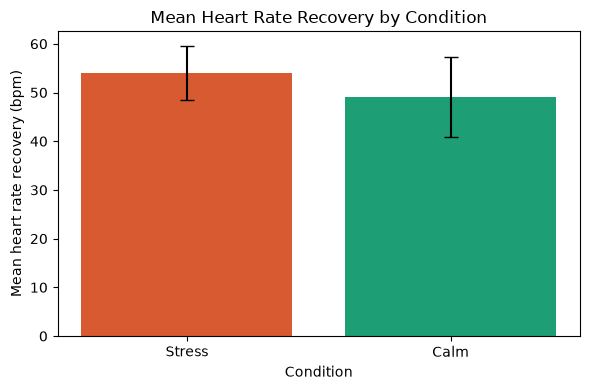

Mean HRR values:
Stress: 54.0
Calm: 49.125
Standard deviations:
Stress: 5.5805785670356025
Calm: 8.219097969276886


In [12]:
# Import libraries for data analysis, graphing, numerical calculations, and file paths
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the final HRR dataset and the figures folder
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the final HRR dataset
df = pd.read_csv(data_path)

# Make sure HRR is treated as numerical data
df["hrr"] = pd.to_numeric(df["hrr"], errors="coerce")

# Separate HRR values by condition
stress_hrr = df[df["condition"] == "stress"]["hrr"].dropna()
calm_hrr = df[df["condition"] == "calm"]["hrr"].dropna()

# Calculate the mean HRR for each condition
means = [stress_hrr.mean(), calm_hrr.mean()]

# Calculate the standard deviation for each condition
stds = [stress_hrr.std(), calm_hrr.std()]

# Set the condition labels and consistent colours
conditions = ["Stress", "Calm"]
colors = ["#D85A30", "#1D9E75"]

# Create the final graph with a clear figure size
plt.figure(figsize=(6, 4))

# Make the bar chart with standard deviation error bars
plt.bar(
    conditions,
    means,
    yerr=stds,
    capsize=5,
    color=colors
)

# Add clear and descriptive axis labels
plt.xlabel("Condition")
plt.ylabel("Mean heart rate recovery (bpm)")

# Add a clear title
plt.title("Mean Heart Rate Recovery by Condition")

# Make the layout fit neatly before saving
plt.tight_layout()

# Save the final graph at 300 dpi for high quality
plt.savefig(figures_folder / "graph1_final.png", dpi=300, bbox_inches="tight")

# Show the graph in the notebook
plt.show()

# Print the values used in the graph
print("Mean HRR values:")
print("Stress:", stress_hrr.mean())
print("Calm:", calm_hrr.mean())

print("Standard deviations:")
print("Stress:", stress_hrr.std())
print("Calm:", calm_hrr.std())

### Graph 1 interpretation

Graph 1 shows that the stress condition had a higher mean HRR than the calm condition. However, the standard deviation error bars show that there was variation within both conditions. This means the graph suggests a possible difference between the two conditions, but the results should still be interpreted carefully because the dataset is small and the t-test did not show a statistically significant difference.

### Final Graph 2: HRR over time by condition

This cell creates Graph 2, which shows how HRR changes across trial number for the stress and calm conditions. This graph helps show whether HRR stayed consistent over time or changed as more trials were completed. This is useful for discussing possible learning effects, fatigue, or other limitations in the final report.

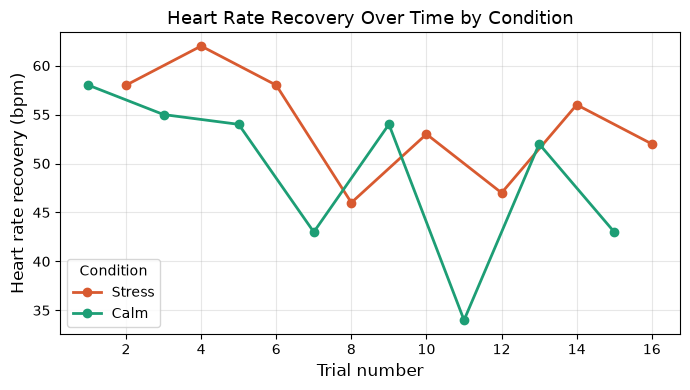

In [13]:
# Import libraries for data analysis, graphing, and file paths
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the final HRR dataset and the figures folder
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the final HRR dataset
df = pd.read_csv(data_path)

# Make sure trial_id and HRR are treated as numerical values
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce")
df["hrr"] = pd.to_numeric(df["hrr"], errors="coerce")

# Separate the dataset by condition and sort each condition by trial number
stress_df = df[df["condition"] == "stress"].sort_values("trial_id")
calm_df = df[df["condition"] == "calm"].sort_values("trial_id")

# Create the final Graph 2 figure
plt.figure(figsize=(7, 4))

# Plot HRR across trial number for the stress condition
plt.plot(
    stress_df["trial_id"],
    stress_df["hrr"],
    marker="o",
    linewidth=2,
    markersize=6,
    color="#D85A30",
    label="Stress"
)

# Plot HRR across trial number for the calm condition
plt.plot(
    calm_df["trial_id"],
    calm_df["hrr"],
    marker="o",
    linewidth=2,
    markersize=6,
    color="#1D9E75",
    label="Calm"
)

# Add clear and descriptive axis labels
plt.xlabel("Trial number", fontsize=12)
plt.ylabel("Heart rate recovery (bpm)", fontsize=12)

# Add a clear title
plt.title("Heart Rate Recovery Over Time by Condition", fontsize=13)

# Make tick labels readable
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a clear legend
plt.legend(title="Condition", fontsize=10, title_fontsize=10)

# Add a light grid to make the trend easier to read
plt.grid(True, alpha=0.3)

# Make the layout fit neatly before saving
plt.tight_layout()

# Save the final graph at 300 dpi for high quality
plt.savefig(figures_folder / "graph2_final.png", dpi=300, bbox_inches="tight")

# Show the graph in the notebook
plt.show()

### Final Graph 3: Individual trial HRR with trendlines

This cell creates the final version of Graph 3. Each dot represents one trial, with trial number on the x-axis and HRR on the y-axis. The dots are separated by condition, and dashed trendlines are added to show whether HRR changed over the course of data collection. The graph is saved at 300 dpi as `graph3_final.png`.

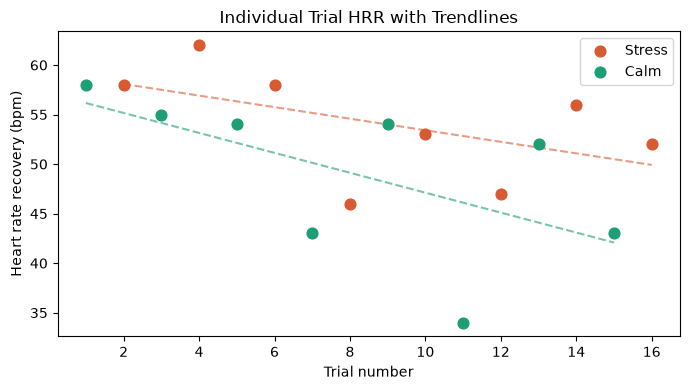

In [14]:
# Import libraries for data analysis, graphing, numerical calculations, and file paths
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the final HRR dataset and the figures folder
data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"

# Create the figures folder if it does not already exist
figures_folder.mkdir(exist_ok=True)

# Load the final HRR dataset
df = pd.read_csv(data_path)

# Make sure trial_id and HRR are treated as numerical values
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce")
df["hrr"] = pd.to_numeric(df["hrr"], errors="coerce")

# Create the figure and axis for Graph 3
fig, ax = plt.subplots(figsize=(7, 4))

# Plot each condition separately so the colours and trendlines match each condition
for condition, color, label in [
    ("stress", "#D85A30", "Stress"),
    ("calm", "#1D9E75", "Calm")
]:
    # Select only the rows for this condition
    subset = df[df["condition"] == condition].copy()

    # Sort by trial number so the trendline is drawn cleanly
    subset = subset.sort_values("trial_id")

    # Plot each individual trial as a dot
    ax.scatter(
        subset["trial_id"],
        subset["hrr"],
        color=color,
        label=label,
        s=60,
        zorder=3
    )

    # Calculate a linear trendline for this condition
    z = np.polyfit(subset["trial_id"], subset["hrr"], 1)
    p = np.poly1d(z)

    # Plot the trendline as a dashed line
    ax.plot(
        subset["trial_id"],
        p(subset["trial_id"]),
        color=color,
        linestyle="--",
        alpha=0.6
    )

# Add clear axis labels
ax.set_xlabel("Trial number")
ax.set_ylabel("Heart rate recovery (bpm)")

# Add a clear title
ax.set_title("Individual Trial HRR with Trendlines")

# Add a legend to show which colour represents each condition
ax.legend()

# Make the layout fit neatly before saving
plt.tight_layout()

# Save Graph 3 at 300 dpi for high quality
plt.savefig(figures_folder / "graph3_final.png", dpi=300, bbox_inches="tight")

# Show the graph in the notebook
plt.show()

### Graph 3 description

Graph 3 shows individual trial variation in HRR across the data collection period. Each dot represents one trial, with trial number on the x-axis and HRR on the y-axis. The stress and calm trials are shown in different colours, and the dashed trendlines show the overall direction of HRR values over time for each condition.

### Results tables and statistical outputs

This section displays the main numerical results from the HRR dataset. It includes a table of all 16 trials, summary statistics for each condition, and the independent samples t-test result comparing HRR between the stress and calm conditions.

In [15]:
# Import libraries for data analysis, file paths, and statistics
import pandas as pd
from pathlib import Path
from scipy import stats

# Find the main project folder.
# If the notebook is inside the "notebooks" folder, move one level up.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Set the path to the final HRR dataset
data_path = project_root / "data" / "hrr_data.csv"

# Load the final HRR dataset
df = pd.read_csv(data_path)

# Make sure trial_id and HRR are treated as numerical values
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")
df["hrr"] = pd.to_numeric(df["hrr"], errors="coerce")

# Sort the dataset by trial number
df = df.sort_values("trial_id").reset_index(drop=True)

# Display the full dataset to confirm it loaded correctly
df

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.0,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,5.5,5.0,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


### Table 1: HRR values for all 16 trials

This table shows the trial number, condition, and HRR value for each of the 16 trials.

In [16]:
# Create a table showing only the columns needed for the Results section
trial_results_table = df[["trial_id", "condition", "hrr"]].copy()

# Format HRR values to 2 decimal places for reporting
trial_results_table["hrr"] = trial_results_table["hrr"].round(2)

# Display the table
trial_results_table

,trial_id,condition,hrr
0,1,calm,58
1,2,stress,58
2,3,calm,55
3,4,stress,62
4,5,calm,54
5,6,stress,58
6,7,calm,43
7,8,stress,46
8,9,calm,54
9,10,stress,53


### Table 2: Summary statistics by condition

This table shows the mean HRR and standard deviation for the stress and calm conditions.

In [17]:
# Calculate mean and standard deviation of HRR for each condition
summary_stats = df.groupby("condition")["hrr"].agg(["mean", "std"]).reset_index()

# Rename columns so the table is easier to read
summary_stats = summary_stats.rename(columns={
    "condition": "Condition",
    "mean": "Mean HRR",
    "std": "Standard Deviation"
})

# Round numbers to 2 decimal places for reporting
summary_stats["Mean HRR"] = summary_stats["Mean HRR"].round(2)
summary_stats["Standard Deviation"] = summary_stats["Standard Deviation"].round(2)

# Display the summary statistics table
summary_stats

,Condition,Mean HRR,Standard Deviation
0,calm,49.12,8.22
1,stress,54.00,5.58


### Independent samples t-test

This cell reports the t-test result comparing HRR between the stress and calm conditions.

In [18]:
# Separate HRR values into stress and calm conditions
stress = df[df["condition"] == "stress"]["hrr"].dropna()
calm = df[df["condition"] == "calm"]["hrr"].dropna()

# Run an independent samples t-test
t_stat, p_val = stats.ttest_ind(stress, calm)

# Calculate degrees of freedom for an independent samples t-test
degrees_freedom = len(stress) + len(calm) - 2

# Format p-value without the leading zero, like .187
p_formatted = f"{p_val:.3f}".replace("0.", ".")

# Print the t-test result in Results-section format
print(f"t({degrees_freedom}) = {t_stat:.2f}, p = {p_formatted}")

t(14) = 1.39, p = .187
